# PCA Method

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import numpy as np



In [7]:
# Load dataset
df = pd.read_csv('../data/city_lifestyle_dataset.csv')

# Basic exploration
print(df.head())

       city_name country  population_density  avg_income  \
0      Old Vista  Europe                2775        3850   
1      Beachport  Europe                3861        3700   
2  Valleyborough  Europe                2562        4310   
3           City  Europe                3192        3970   
4          Falls  Europe                3496        4320   

   internet_penetration  avg_rent  air_quality_index  public_transport_score  \
0                  86.4      1310                 43                    52.0   
1                  78.1      1330                 42                    62.8   
2                  80.1      1330                 39                    73.2   
3                  81.2      1480                 60                    49.2   
4                 100.0      1510                 64                    93.7   

   happiness_score  green_space_ratio  
0              8.5               23.8  
1              8.1               33.1  
2              8.5               40.2 

In [6]:
print(df.describe())


       population_density   avg_income  internet_penetration     avg_rent  \
count          300.000000   300.000000            300.000000   300.000000   
mean          3944.843333  2827.200000             74.305333  1002.766667   
std           2982.566777  1201.163939             17.014492   456.282066   
min            100.000000   480.000000             34.000000   170.000000   
25%           1830.000000  1907.500000             64.400000   640.000000   
50%           3083.500000  2810.000000             75.000000   990.000000   
75%           4823.750000  3752.500000             87.225000  1332.500000   
max          14427.000000  5720.000000            100.000000  2430.000000   

       air_quality_index  public_transport_score  happiness_score  \
count         300.000000              300.000000       300.000000   
mean           71.246667               55.717333         6.644000   
std            25.344961               14.712549         1.685864   
min            22.000000      

In [8]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city_name               300 non-null    object 
 1   country                 300 non-null    object 
 2   population_density      300 non-null    int64  
 3   avg_income              300 non-null    int64  
 4   internet_penetration    300 non-null    float64
 5   avg_rent                300 non-null    int64  
 6   air_quality_index       300 non-null    int64  
 7   public_transport_score  300 non-null    float64
 8   happiness_score         300 non-null    float64
 9   green_space_ratio       300 non-null    float64
dtypes: float64(4), int64(4), object(2)
memory usage: 23.6+ KB
None


### Visualisation de la matrice de corrélation

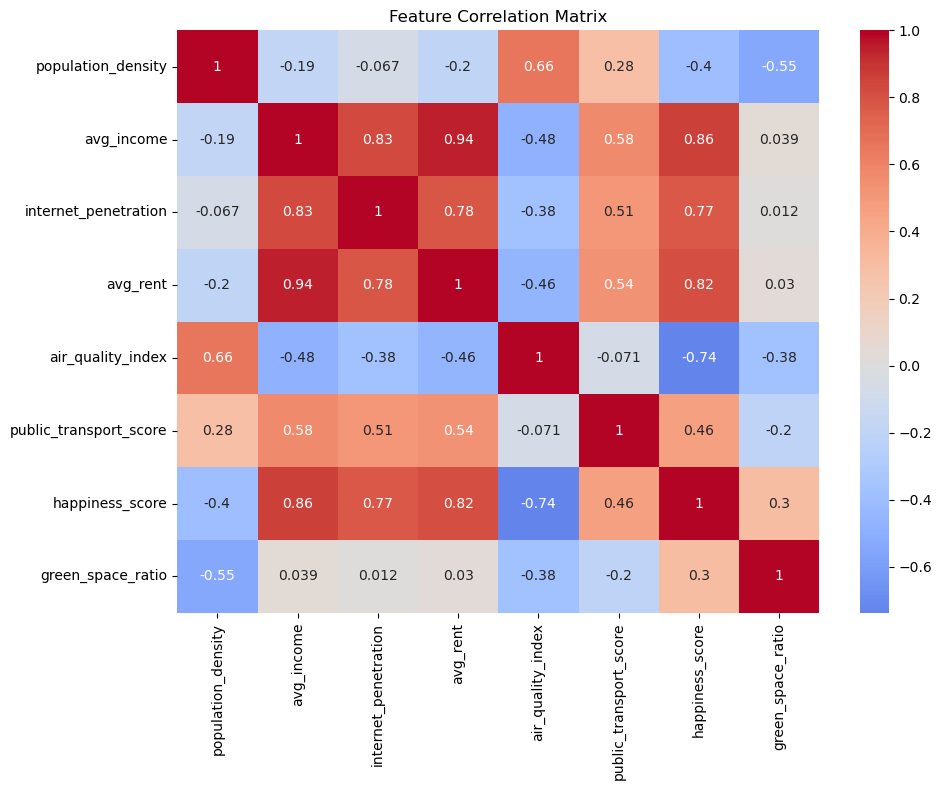

happiness_score           1.000000
avg_income                0.857973
avg_rent                  0.815334
internet_penetration      0.769926
public_transport_score    0.463903
green_space_ratio         0.297964
population_density       -0.399571
air_quality_index        -0.737528
Name: happiness_score, dtype: float64

In [10]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include='number').corr(), 
            annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

corr = df.select_dtypes(include='number').corr()

corr['happiness_score'].sort_values(ascending=False)


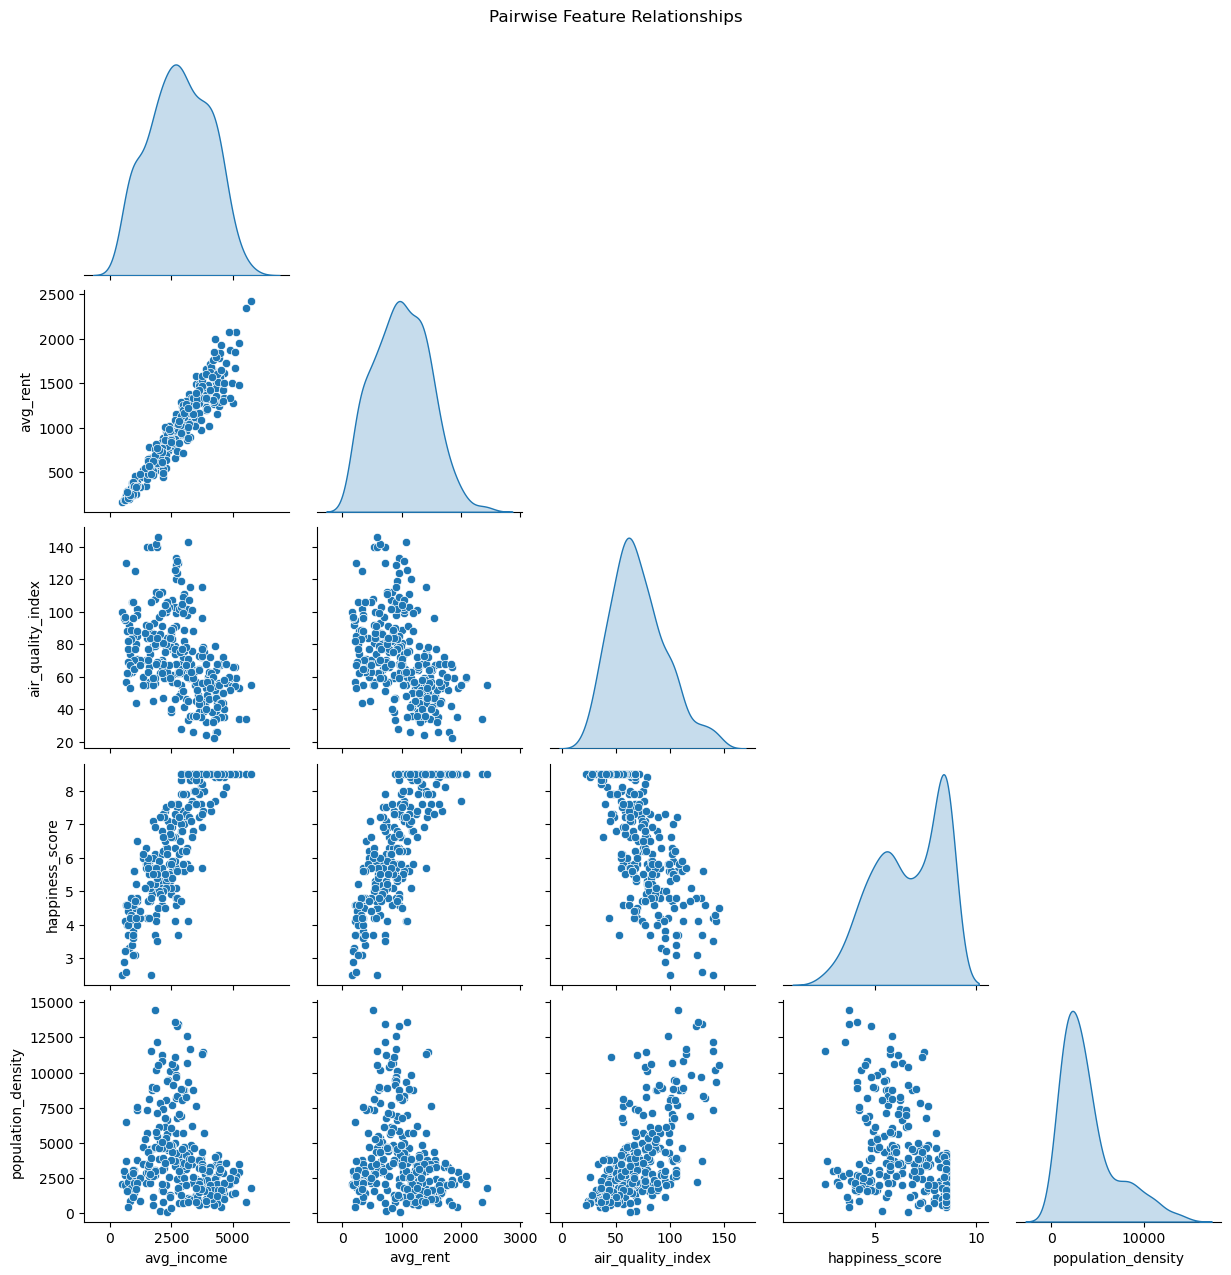

In [11]:
subset = ['avg_income', 'avg_rent', 'air_quality_index', 'happiness_score', 'population_density']
subset = [col for col in subset if col in df.columns]
if subset:
    sns.pairplot(df[subset], diag_kind='kde', corner=True)
    plt.suptitle("Pairwise Feature Relationships", y=1.02)
    plt.show()

## PCA — Dimensionality Reduction

In [14]:
# Prepare data for clustering
X = df.drop(['city_name', 'country'], axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# PCA visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df['PC1'] = X_pca[:,0]
df['PC2'] = X_pca[:,1]

print("Ratio de variance expliquée:", np.round(pca.explained_variance_ratio_, 3))


Ratio de variance expliquée: [0.53  0.307]


c:\Users\PrecyGASSAILEPOMA\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


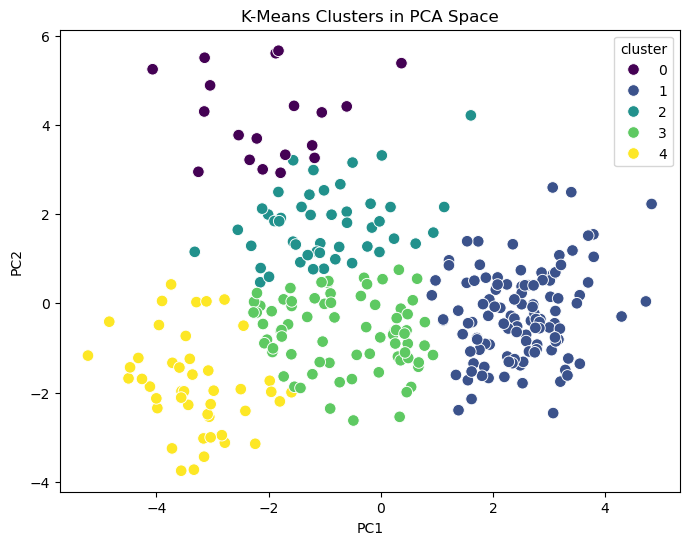

,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio,PC1,PC2,cluster
cluster,,,,,,,,,,,
0,11006.2,2575.3,74.1,896.3,124.7,68.5,4.6,18.0,-2.0,4.2,0.0
1,2228.0,4054.0,88.8,1453.8,51.1,62.5,8.4,36.7,2.5,-0.3,1.0
2,7575.9,2514.0,72.1,877.4,88.4,61.9,6.0,27.2,-1.0,1.8,2.0
3,3390.6,2317.5,70.2,818.8,71.2,49.7,6.4,36.0,-0.7,-0.7,3.0
4,2443.9,1002.2,46.8,342.7,82.0,36.7,4.3,37.5,-3.3,-1.8,4.0


In [17]:
kmeans = KMeans(n_clusters=5, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x='PC1', y='PC2', data=df, hue='cluster', palette='viridis', s=70)
plt.title("K-Means Clusters in PCA Space")
plt.show()

df.groupby('cluster')[df.select_dtypes(include=[np.number]).columns].mean().round(1)

### Observation 

L’analyse en composantes principales (83,7 % de variance expliquée) révèle une structuration nette des données en cinq groupes distincts. La projection en espace PCA montre une bonne séparation des clusters, notamment entre le cluster 1, caractérisé par des revenus élevés, une forte pénétration Internet et une meilleure qualité de l’air, et le cluster 4, qui regroupe des villes à faibles revenus et faibles niveaux d’infrastructure.

Les clusters centraux (2 et 3) présentent des profils intermédiaires, tandis que le cluster 0 se distingue par une forte densité de population et une qualité de l’air plus dégradée. Globalement, la structure obtenue met en évidence un gradient socio-économique et infrastructurel clair, confirmant la cohérence du partitionnement par K-means.